In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("Downloads/fuel-econ.csv")
df.shape

(3929, 20)

In [3]:
df.head()

,id,make,model,year,VClass,drive,trans,fuelType,cylinders,displ,pv2,pv4,city,UCity,highway,UHighway,comb,co2,feScore,ghgScore
0,32204,Nissan,GT-R,2013,Subcompact Cars,All-Wheel Drive,Automatic (AM6),Premium Gasoline,6,3.8,79,0,16.4596,20.2988,22.5568,30.1798,18.7389,471,4,4
1,32205,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (AM-S6),Premium Gasoline,4,2.0,94,0,21.8706,26.9770,31.0367,42.4936,25.2227,349,6,6
2,32206,Volkswagen,CC,2013,Compact Cars,Front-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,94,0,17.4935,21.2000,26.5716,35.1000,20.6716,429,5,5
3,32207,Volkswagen,CC 4motion,2013,Compact Cars,All-Wheel Drive,Automatic (S6),Premium Gasoline,6,3.6,94,0,16.9415,20.5000,25.2190,33.5000,19.8774,446,5,5
4,32208,Chevrolet,Malibu eAssist,2013,Midsize Cars,Front-Wheel Drive,Automatic (S6),Regular Gasoline,4,2.4,0,95,24.7726,31.9796,35.5340,51.8816,28.6813,310,8,8


In [4]:
df["trans_type"] = df["trans"].apply(lambda x:x.split()[0])

In [5]:
np.random.seed(2018)
sample = np.random.choice(df.shape[0], 200, replace=False)
df_subset = df.loc[sample]

### Plot 1: Fuel Efficiency and Transmission Type

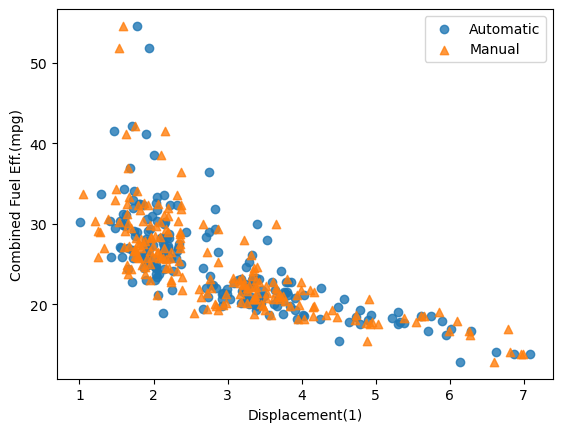

In [6]:
ttype_markers = [["Automatic", "o"],
                ["Manual", "^"]]

for ttype, marker in ttype_markers:
    plot_data = df_subset.loc[df["trans_type"] == ttype]
    sns.regplot(data=df_subset, x="displ", y="comb", 
               x_jitter=0.4, fit_reg=False, marker=marker);
plt.xlabel("Displacement(1)")
plt.ylabel("Combined Fuel Eff.(mpg)")
plt.legend(["Automatic", "Manual"]);   

### Plot 2: Fuel Efficiency and C02 Emissions

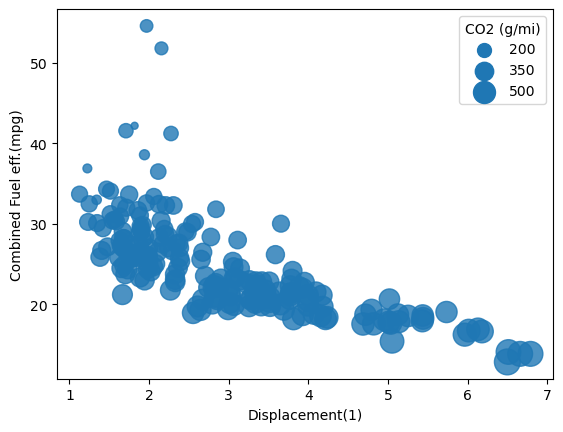

In [7]:
sns.regplot(data=df_subset, x="displ", y="comb",
           x_jitter=0.4, fit_reg=False, scatter_kws={"s":df_subset["co2"]/2});
plt.xlabel("Displacement(1)")
plt.ylabel("Combined Fuel eff.(mpg)");

sizes = [200, 350, 500]
legend_obj = []
for s in sizes:
    legend_obj.append(plt.scatter([], [], s=s/2, color="tab:blue"))
plt.legend(legend_obj, sizes, title="CO2 (g/mi)");

### Encoding via Shape

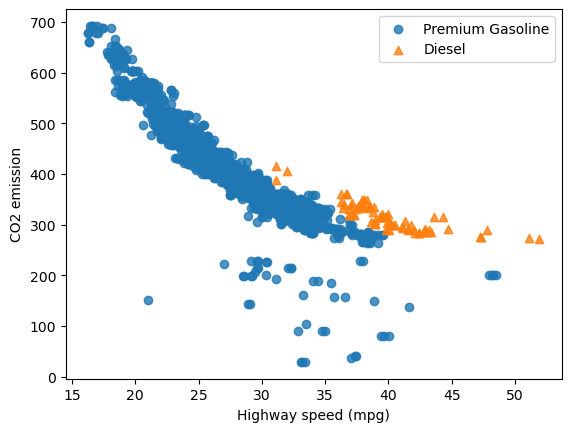

In [8]:
ttype_marker = [["Premium Gasoline", "o"],
               ["Diesel", "^"]]

for ttype, marker in ttype_marker:
    plot_data = df.loc[df["fuelType"] == ttype]
    sns.regplot(data = plot_data, x="highway", y="co2",
               x_jitter=0.4, fit_reg=False, marker=marker);
plt.xlabel("Highway speed (mpg)")
plt.ylabel("CO2 emission");
plt.legend(["Premium Gasoline", "Diesel"]);

### Encoding via Size

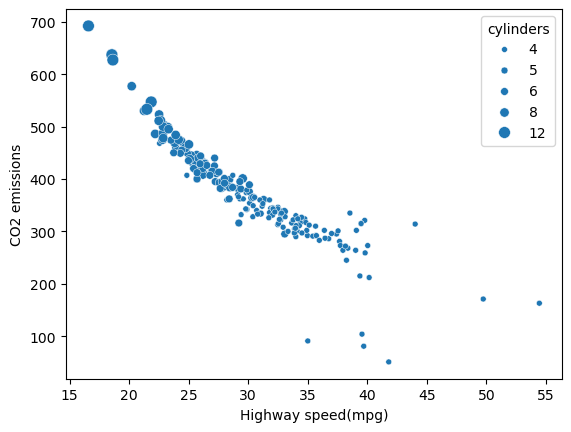

In [9]:
sns.scatterplot(data=df_subset, x="highway", y="co2", size="cylinders", color="tab:blue")
plt.xlabel("Highway speed(mpg)")
plt.ylabel("CO2 emissions");